In [ ]:
# Importing Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
import warnings
warnings.filterwarnings('ignore')



In [ ]:
# Running Complete Preprocessing Pipeline

import sys                  # sys module lets us modify where Python

sys.path.append('..')

from src.preprocess import run_preprocessing_pipeline

df_raw, df_clean, df_encoded, feature_columns = run_preprocessing_pipeline('../data/raw/telco_churn.csv')

print(f"\n Variables ready to use:")
print(f"df_raw shape:      {df_raw.shape}")
print(f"df_clean shape:    {df_clean.shape}")
print(f"df_encoded shape:  {df_encoded.shape}")
print(f"Feature columns:   {len(feature_columns)}")

In [ ]:
# First Look at Raw Data
print("Dataset Info:")
df_raw.info()

print('\n')

print('Unique values per column:')
display(df_raw.nunique())

In [ ]:
# Quick EDA: Class Imbalance
churn_counts = df_raw['Churn'].value_counts()
print(churn_counts)

for value, count in churn_counts.items():

    percentage = (count / (len(df_raw))) * 100
    print(f'{value} : {count} Customers ({percentage:.1f}%)')

print()

fig, ax = plt.subplots(1, 2, figsize = (12, 5))

#Bar Chart
bars = ax[0].bar(churn_counts.index, 
                 churn_counts.values, 
                 color = ['skyblue', 'salmon'],
                 edgecolor = 'white',
                 linewidth = 1.5, 
                 width = 0.5)

for bar, value in zip(bars, churn_counts.values):
    ax[0].text(bar.get_x() + bar.get_width()/2  ,
               bar.get_height() + 50,
               f'{value:,}',
               ha = 'center',
               fontweight = 'bold',
               fontsize = 10)
    
ax[0].set_title('Customer Churn Distribution', fontsize = 12, fontweight = 'bold')
ax[0].set_xlabel('Churn Status', fontsize = 10, fontweight = 'bold')
ax[0].set_ylabel('Num of Customers', fontsize = 10, fontweight = 'bold')

#Pie Chart
ax[1].pie(churn_counts.values, 
          labels = ['Not Churned', 'Churned'],
          autopct = '%1.1f%%',
          colors = ['skyblue', 'salmon'],
          startangle = 90,  
          explode = (0.01, 0.01)) 

ax[1].set_title('Customer Churn Distribution %', fontsize = 12, fontweight = 'bold')

plt.tight_layout()
plt.savefig('../outputs/01_churn_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# Complete Missing Value Audit
print("COMPLETE MISSING VALUE AUDIT")
print("=" * 55)

# Checking True NaN values
print("\n Checking True NaN Missing Values")
print("─" * 40)
true_missing = df_raw.isnull().sum()
true_missing_cols = true_missing[true_missing > 0]
if len(true_missing_cols) == 0:
    print("No true NaN missing values found!")
else:
    print(true_missing_cols)

# Checking Disguised missing values in text columns
print("\nChecking Disguised Missing in Text Columns")
print("─" * 40)
text_cols = df_raw.select_dtypes(include='object').columns
for col in text_cols:
    disguised = df_raw[col].str.strip().eq('').sum()
    placeholders = df_raw[col].str.lower().isin(
        ['n/a', 'na', 'none', 'unknown', 'null', '?', '-']
    ).sum()
    total = disguised + placeholders
    if total > 0:
        print(f"{col}: {total} disguised missing values")
    else:
        print(f"{col}: Clean")

# Checking Zeros in numerical columns
print("\nChecking Zero Values in Numerical Columns")
print("─" * 40)
num_cols = df_raw.select_dtypes(include=['int64','float64']).columns
for col in num_cols:
    zero_count = (df_raw[col] == 0).sum()
    if zero_count > 0:
        print(f"ℹ{col}: {zero_count} zeros "
              f"(verify if 0 is valid here)")

print("\nSUMMARY")
print("─" * 40)
print(f"Total rows: {len(df_raw)}")
print(f"Total columns: {len(df_raw.columns)}")
print(f"True NaN: {df_raw.isnull().sum().sum()}")


In [ ]:
# Basic Statistics
print("NUMERICAL COLUMNS SUMMARY:")
print("─" * 40)

display(df_raw.describe().round(2))

print("\nCATEGORICAL COLUMNS SUMMARY:")
print("─" * 40)

display(df_raw.describe(include='object'))

In [ ]:
# Final Cleaning Verification

print("CLEANING VERIFICATION:")
print("─" * 40)
print(f"Rows:                  {df_encoded.shape[0]}")
print(f"Columns:               {df_encoded.shape[1]}")
print(f"Missing values:        {df_encoded.isnull().sum().sum()}")
print(f"Churn values:          {df_encoded['Churn'].unique()}")
print(f"Text columns left:     "
      f"{len(df_encoded.select_dtypes(include='object').columns)}")

# Checking specific expected values
assert df_encoded.shape[0] == 7032, "Row count wrong!"
assert df_encoded.shape[1] < 100,   "Too many columns!"
assert df_encoded.isnull().sum().sum() == 0, "Missing values!"
assert df_encoded['Churn'].nunique() == 2, "Churn not encoded!"

print("\nAll checks passed")

In [ ]:
# Deep EDA: Churn by Contract Type
print("CHURN RATE BY CONTRACT TYPE:")
churn_by_contract = df_clean.groupby('Contract')['Churn'].value_counts(normalize = True).unstack()
print(churn_by_contract)

# ── ax[0]: Stacked Bar Chart 
churn_by_contract_pct = (churn_by_contract*100).round(1)  
print()  
print(churn_by_contract_pct)

fig, ax = plt.subplots(1, 2, figsize =(14, 6))
churn_by_contract_pct.plot(kind = 'bar', 
                           stacked = True, 
                           ax = ax[0],
                           color = ['#20B2AA', '#F4B400'],
                           edgecolor = 'white',
                           width = 0.5,
                           rot = 0)
ax[0].set_title('Churn Rate by Contract Type(%)',
                   fontsize=13, fontweight='bold')
ax[0].set_xlabel('Contract Type', fontsize=12,fontweight='bold')
ax[0].set_ylabel('Percentage (%)', fontsize=12,fontweight='bold')
ax[0].legend(['No Churn (No)', 'Churned (Yes)'], fontsize=10)

for i, (contract, row) in enumerate(churn_by_contract_pct.iterrows()):
    churn_pct = row[0]
    ax[0].text(i, churn_pct / 2,
                f'{churn_pct}%',
                 ha = 'center',
                 va = 'center',
                 fontweight='bold',
                 fontsize=12,
                 color='white' )
    
# ax[1] : Horizontal Bar Chart of Churn Rate Only
churn_only = churn_by_contract_pct[1].sort_values(ascending=True)
colors = ['#27ae60', '#f39c12', '#e74c3c']
bars = ax[1].barh(churn_only.index,
                  churn_only.values,
                  color = colors,
                  edgecolor='white',
                  height=0.5)
for bar, value in zip(bars, churn_only.values):
    ax[1].text(
        bar.get_width() + 0.5,
                bar.get_y() + bar.get_height()/2,
        f'{value:.1f}%',
        va='center',
        fontweight='bold',
        fontsize=12
    )

ax[1].set_title('Churn Rate % by Contract Type',
                   fontsize=13, fontweight='bold')
ax[1].set_xlabel('Churn Rate (%)', fontsize=12,fontweight='bold')
ax[1].set_ylabel('Contract Type', fontsize=12,fontweight='bold')
ax[1].set_xlim(0, 55)

plt.tight_layout()
plt.savefig('../outputs/02_churn_by_contract.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\n CHURN BY CONTRACT TYPE RESULT:")
print("─" * 45)
for contract, row in churn_by_contract_pct.iterrows():
    print(f"{contract:20s} → Churn Rate: {row[1]:.1f}%")


In [ ]:
# Deep EDA: Churn BY Tenure

# Chart 1: Histogram
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

no_churn_tenure = df_clean[df_clean['Churn'] == 0]['tenure']
yes_churn_tenure = df_clean[df_clean['Churn'] == 1]['tenure']

axes[0].hist(no_churn_tenure, 
            bins = 30,
            alpha = 0.6, 
            color='#2ecc71',
            label='Not Churned',
            edgecolor='white')

axes[0].hist(yes_churn_tenure,
             bins = 30,
             alpha = 0.6,
             color='#e74c3c',
             label='Churned',
             edgecolor='white')

axes[0].set_title('Tenure Distribution by Churn',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Tenure (Months)', fontsize=11)
axes[0].set_ylabel('Number of Customers', fontsize=11)
axes[0].legend(fontsize=10)

#Chart 2: Box plot
sns.boxplot(x = 'Churn', 
            y = 'tenure',
            data = df_clean,
            ax = axes[1],
            palette={'1': '#e74c3c', '0': '#2ecc71'},
            linewidth = 1.5)

axes[1].set_title('Tenure Box Plot by Churn',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Churned?', fontsize=11)
axes[1].set_ylabel('Tenure (Months)', fontsize=11)
axes[1].set_xticklabels(['No', 'Yes'])

# Chart 3: KDE Plot (Smooth Distribution)
sns.kdeplot(data = df_clean, 
            x = 'tenure', 
            hue = 'Churn',  
            fill=True,
            ax = axes[2],
            alpha=0.4,
            linewidth = 1.5,
            palette={0: '#2ecc71', 1: '#e74c3c'})

axes[2].set_title('Tenure Density by Churn',
                   fontsize=13, fontweight='bold')
axes[2].set_xlabel('Tenure (Months)', fontsize=11)
axes[2].set_ylabel('Density', fontsize=11)
axes[2].legend(['Churned', 'Not Churned'], fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/03_tenure_vs_churn.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nChurn BY Tenure:")
print("─" * 45)
print(f"Not Churned  → Median tenure: "
      f"{no_churn_tenure.median():.0f} months")
print(f"Churned → Median tenure: "
      f"{yes_churn_tenure.median():.0f} months")
print(f"\nConclusion: Churners leave after only "
      f"{yes_churn_tenure.median():.0f} months on average!")

In [ ]:
# Deep EDA: Churn by Monthly Charges 

# Chart 1: Box Plot with Mean Overlay
fig, axes = plt.subplots(1, 2, figsize = (14, 6))

sns.boxplot(x = 'Churn',
            y = 'MonthlyCharges',
            data = df_clean,
            ax = axes[0],
            palette={'0': '#2ecc71', '1': '#e74c3c'},
            linewidth = 1.5)
    
no_churn_mean = df_clean[df_clean['Churn'] == 0]['MonthlyCharges'].mean()
yes_churn_mean = df_clean[df_clean['Churn'] == 1]['MonthlyCharges'].mean()

axes[0].scatter([0, 1],
                [no_churn_mean, yes_churn_mean],
                marker = 'D',
                color = 'white',
                zorder = 3,
                s = 50)

axes[0].set_title('Monthly Charges by Churn\n'
                   '(Diamond = Mean)',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Churned?', fontsize=11)
axes[0].set_ylabel('Monthly Charges ($)', fontsize=11)
axes[0].set_xticklabels(['No', 'Yes'])

#Chart 2: KDE Plot
sns.kdeplot(data = df_clean,
            x = 'MonthlyCharges',
            hue = 'Churn',
            fill = True,    
            ax = axes[1],   
            alpha = 0.4,
            linewidth = 0.5,
            palette={0: '#2ecc71', 1: '#e74c3c'})    

axes[1].legend(['Churned', 'Not Churned'], fontsize=10)  

axes[1].axvline(               # axvline → draws a vertical line at x position
    x=no_churn_mean,
    color='#2ecc71',
    linestyle='--',   
    linewidth=1.5,
    label=f'No Churn Mean: ${no_churn_mean:.0f}'
)

axes[1].axvline(
    x=yes_churn_mean,
    color='#e74c3c',
    linestyle='--',
    linewidth=1.5,
    label=f'Churned Mean: ${yes_churn_mean:.0f}'
)

axes[1].set_title('Monthly Charges Distribution',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Monthly Charges ($)', fontsize=11)
axes[1].set_ylabel('Density', fontsize=11)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('../outputs/04_monthly_charges_churn.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\n Churn by Monthly Charges Results:")
print("─" * 45)
print(f"Stayed  → Avg Monthly Charges: ${no_churn_mean:.2f}")
print(f"Churned → Avg Monthly Charges: ${yes_churn_mean:.2f}")
print(f"Difference: ${yes_churn_mean - no_churn_mean:.2f} more "
      f"per month for churners!")

In [ ]:
# Deep EDA: Correlation Heatmap
correlation_matrix = df_encoded.corr()

churn_correlation = correlation_matrix['Churn'].drop('Churn').sort_values(ascending=False)

print("CORRELATION WITH CHURN (sorted high to low):")
print("─" * 50)
print(churn_correlation.round(3))

top_features = churn_correlation.abs().sort_values(ascending=False).head(15).index

top_features_with_churn = top_features.to_list() + ['Churn']
top_corr = df_encoded[top_features_with_churn].corr()

fig, ax = plt.subplots(figsize=(14, 10))

sns.heatmap(top_corr,
            annot = True,
            fmt = '.2f',
            cmap = 'RdYlGn',
            center = 0,
            linewidth = 0.5,
            annot_kws={'size': 9},
            ax = ax,
            square = True)

ax.set_title('Correlation Heatmap\n(Top 15 Features vs Churn)',
             fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/05_correlation_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\nTOP 5 FEATURES POSITIVELY CORRELATED WITH CHURN:")
print("─" * 50)
print(churn_correlation.head(5))
print("\nTOP 5 FEATURES NEGATIVELY CORRELATED WITH CHURN:")
print("─" * 50)
print(churn_correlation.tail(5))

In [ ]:
# Deep EDA Summary

print("DEEP EDA COMPLETE — KEY FINDINGS SUMMARY")
print("=" * 55)

print("""
    1. MONTH-TO-MONTH CUSTOMERS CHURN MORE
       Month-to-month: 42.7% churn rate
       Two year:        2.9% churn rate
       Impact: 15x difference!)

    2. New customers churn more 
       Churners median tenure:  10 months
       Stayers  median tenure:  38 months
       Impact: First year is CRITICAL!
      
    3. Higher charges = more churn         
       Churners avg charge:  $74.44/month
       Stayers  avg charge:  $61.27/month
       Impact: $13 difference per month
      
      
      
    MOST IMPORTANT FEATURES FOR ML MODEL:
───────────────────────────────────────────────────────
1. tenure              (correlation: -0.35)
2. Contract_Two year   (correlation: -0.30)
3. MonthlyCharges      (correlation: +0.19)
4. TotalCharges        (correlation: -0.20)
5. Contract_One year   (correlation: -0.18)
      
      
      
    BUSINESS RECOMMENDATIONS:
───────────────────────────────────────────────────────
1. Focus retention efforts on first 12 months
2. Incentivize customers to sign longer contracts
3. Offer price-lock guarantees to high-paying customers
4. Create early warning system for month-to-month
   customers with high charges and low tenure
      """)

In [ ]:
# Feature Engineering
print(f"\nShape BEFORE feature engineering: {df_clean.shape}")

df_features = df_clean.copy()

# FEATURE 1 — tenure_group
def assign_tenure_group(tenure):
    """
    Assigns a tenure group label based on months.

    Parameters:
    -----------
    tenure : int
        Number of months customer has been with company

    Returns:
    --------
    str : Group label ('New', 'Mid', or 'Loyal')
    """
    
df_features['tenure_group'] = pd.cut(

    df_features['tenure'],

    bins=[-1, 12, 48, 72],

    labels=['New', 'Mid', 'Loyal']

)

print("\nFEATURE 1: tenure_group created")
print("Distribution:")
print(df_features['tenure_group'].value_counts())

print("\nChurn rate by tenure group:")
tenure_churn = df_features.groupby('tenure_group')['Churn'].mean() * 100
print(tenure_churn.round(1))

# FEATURE 2 — total_services

service_columns = [
    'PhoneService',
    'MultipleLines',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]
df_features['total_services'] = (df_features[service_columns] == 'Yes').sum(axis=1)
print("\nFEATURE 2: total_services created!")
print("Distribution:")
print(df_features['total_services'].value_counts().sort_index())

print("\nChurn rate by service count:")
service_churn = df_features.groupby('total_services')['Churn'].mean() * 100
print(service_churn.round(1))

# FEATURE 3 — is_new_customer
df_features['is_new_customer'] = (df_features['tenure'] <= 12).astype(int)
print("\nFEATURE 3: is_new_customer created!")
print("Distribution:")
print(df_features['is_new_customer'].value_counts())

print("\nChurn rate: New vs Not New:")
new_churn = df_features.groupby('is_new_customer')['Churn'].mean() * 100
print(new_churn.round(1))

# FEATURE 4 — avg_monthly_from_total
df_features['avg_monthly_from_total'] = (
    df_features['TotalCharges'] /
    df_features['tenure'].replace(0, 1))

print("\nFEATURE 4: avg_monthly_from_total created!")
print(f"Mean: ${df_features['avg_monthly_from_total'].mean():.2f}")
print(f"Min:  ${df_features['avg_monthly_from_total'].min():.2f}")
print(f"Max:  ${df_features['avg_monthly_from_total'].max():.2f}")

# FEATURE 5 — high_value_customer
median_charges = df_features['MonthlyCharges'].median()
df_features['high_value_customer'] = (df_features['MonthlyCharges'] > median_charges).astype(int)
print("\nFEATURE 5: high_value_customer created!")
print(f"Median monthly charges: ${median_charges:.2f}")
print(f"High value customers: "
      f"{df_features['high_value_customer'].sum()}")

print("\nChurn rate: High value vs Normal:")
hv_churn = df_features.groupby(
    'high_value_customer'
)['Churn'].mean() * 100
print(hv_churn.round(1))

# SUMMARY
print("\n" + "=" * 55)
print("FEATURE ENGINEERING COMPLETE!")
print("=" * 55)
print(f"Shape BEFORE: {df_clean.shape}")
print(f"Shape AFTER:  {df_features.shape}")
print(f"\nNew features added:")
new_features = ['tenure_group', 
                'total_services',
                'is_new_customer',
                'avg_monthly_from_total',
                'high_value_customer']
for f in new_features:
    print(f)


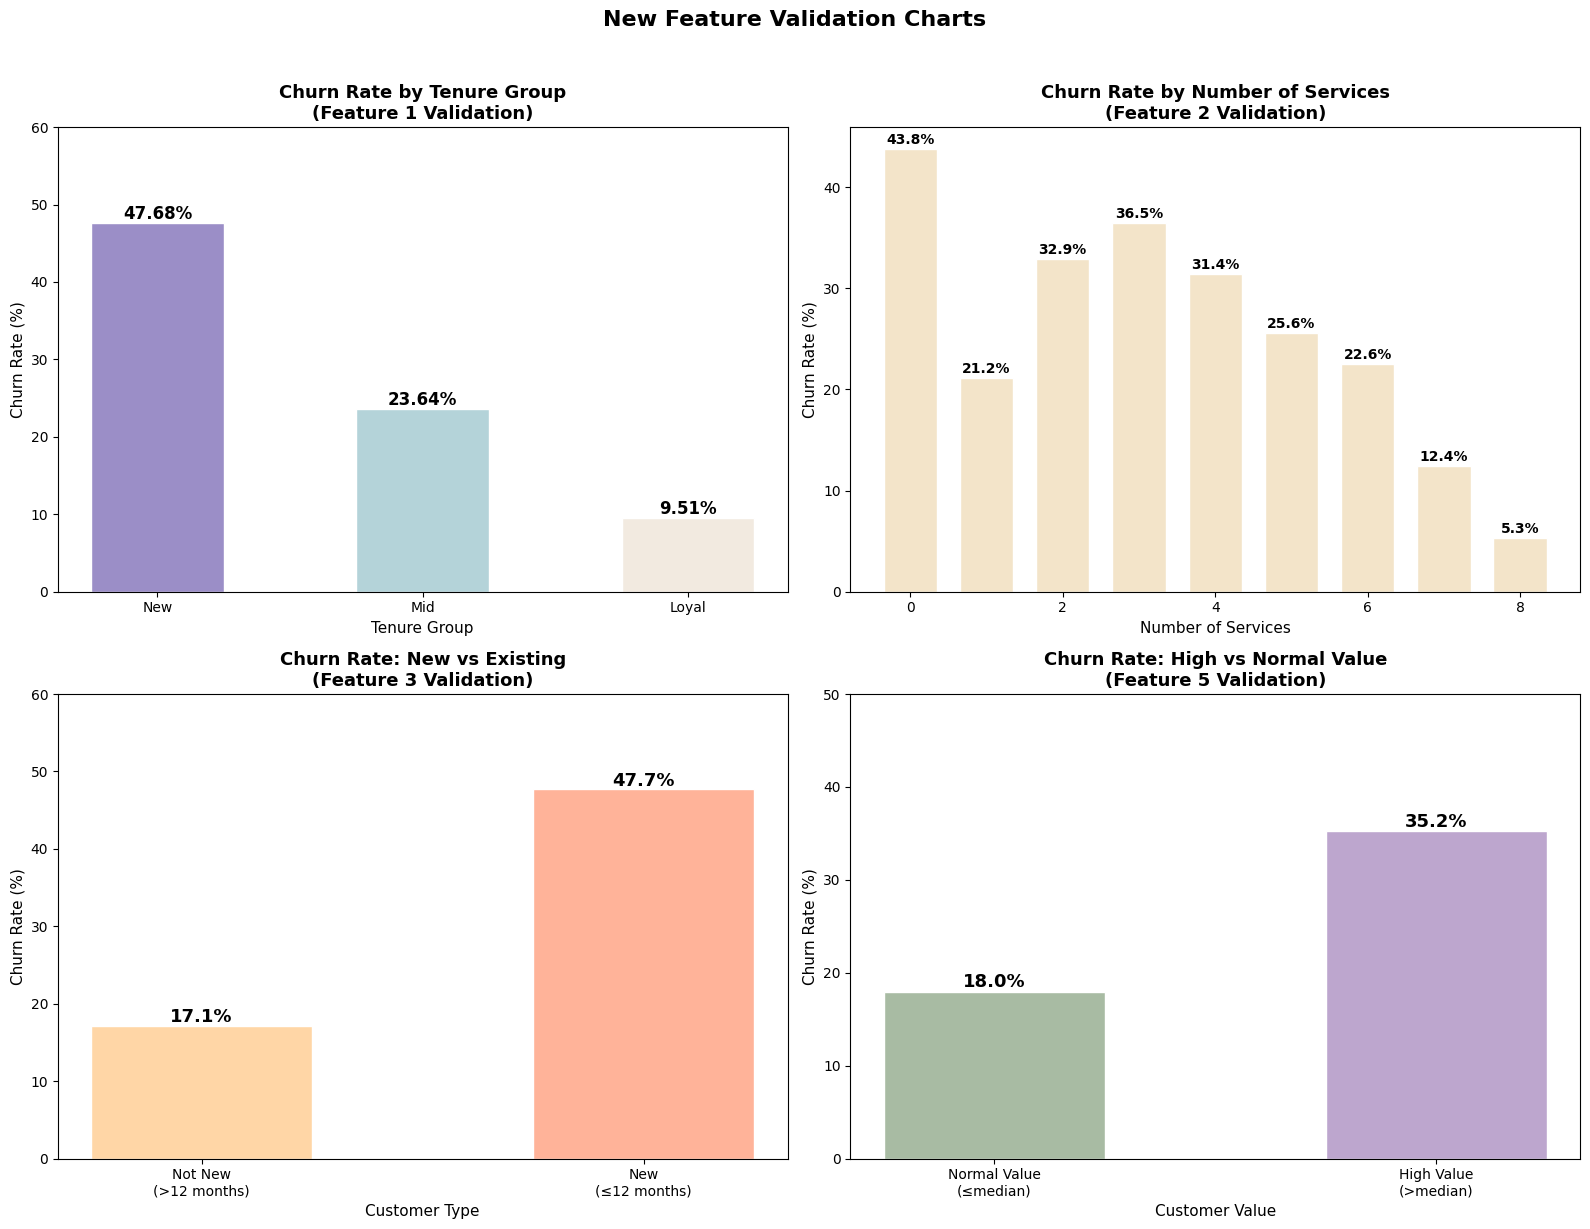

Feature validation charts saved!


In [55]:
# Visualizing New Features

fig, axes = plt.subplots(2, 2, figsize = (16, 12))

# Chart 1: Churn by Tenure Group
order = ['New', 'Mid', 'Loyal']
tenure_churn_ordered = tenure_churn.reindex(order)
colors = ['#9B8EC7', '#B4D3D9', '#F2EAE0']

bars = axes[0, 0].bar(tenure_churn_ordered.index,
                      tenure_churn_ordered.values,
                      color = colors,
                      edgecolor='white',
                      width=0.5)

for bar, value in zip(bars, tenure_churn_ordered):
    axes[0, 0].text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.5,
                    f'{value:.2f}%',
                    ha='center',
                    fontweight='bold',
                    fontsize=12)

axes[0, 0].set_title('Churn Rate by Tenure Group\n'
                      '(Feature 1 Validation)',
                      fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Tenure Group', fontsize=11)
axes[0, 0].set_ylabel('Churn Rate (%)', fontsize=11)
axes[0, 0].set_ylim(0, 60)

# Chart 2: Churn by Total Services
bars2 = axes[0, 1].bar(service_churn.index,
                       service_churn.values,
                       color='#F3E4C9',
                       edgecolor='white',
                       width=0.7)

for bar, value in zip(bars2, service_churn.values):
    axes[0, 1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{value:.1f}%',
        ha='center',
        fontweight='bold',
        fontsize=10
    )

    axes[0, 1].set_title('Churn Rate by Number of Services\n'
                      '(Feature 2 Validation)',
                      fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Number of Services', fontsize=11)
axes[0, 1].set_ylabel('Churn Rate (%)', fontsize=11)

# Chart 3: New Customer Churn 

colors3 = ['#FFD6A6', '#FFB399']
labels = ['Not New\n(>12 months)', 'New\n(≤12 months)']

bars3 = axes[1, 0].bar(
    labels,
    new_churn.values,
    color=colors3,
    edgecolor='white',
    width=0.5
)

for bar, value in zip(bars3, new_churn.values):
    axes[1, 0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{value:.1f}%',
        ha='center',
        fontweight='bold',
        fontsize=13
    )

axes[1, 0].set_title('Churn Rate: New vs Existing\n'
                      '(Feature 3 Validation)',
                      fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Customer Type', fontsize=11)
axes[1, 0].set_ylabel('Churn Rate (%)', fontsize=11)
axes[1, 0].set_ylim(0, 60)

# Chart 4: High Value Customer Churn 

labels4 = ['Normal Value\n(≤median)', 'High Value\n(>median)']
colors4 = ['#A8BBA3', '#BDA6CE']

bars4 = axes[1, 1].bar(
    labels4,
    hv_churn.values,
    color=colors4,
    edgecolor='white',
    width=0.5
)

for bar, value in zip(bars4, hv_churn.values):
    axes[1, 1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{value:.1f}%',
        ha='center',
        fontweight='bold',
        fontsize=13
    )

axes[1, 1].set_title('Churn Rate: High vs Normal Value\n'
                      '(Feature 5 Validation)',
                      fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Customer Value', fontsize=11)
axes[1, 1].set_ylabel('Churn Rate (%)', fontsize=11)
axes[1, 1].set_ylim(0, 50)

plt.suptitle('New Feature Validation Charts',
             fontsize=16, fontweight='bold', y=1.02)
# suptitle → super title above all charts

plt.tight_layout()
plt.savefig('../outputs/06_feature_validation.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Feature validation charts saved!")

In [57]:
# Re-encode Dataset With New Features

print("Re-encoding dataset with new features...")
print(f"Shape before: {df_features.shape}")

categorical_cols = df_features.select_dtypes(include='object').columns.tolist()

print(f"Text columns to encode: {categorical_cols}")

df_final = pd.get_dummies(df_features, 
                          columns = categorical_cols,
                          drop_first=True)

print(f"Shape after:  {df_final.shape}")

feature_columns_final = [col for col in df_final.columns if col != 'Churn']
print(f"\nFinal feature count: {len(feature_columns_final)}")
print("\nFinal dataset ready for ML!")

assert df_final.select_dtypes(
    include='object'
).shape[1] == 0, "Still has text columns!"

assert 'Churn' in df_final.columns, \
    "Churn column missing!"



Re-encoding dataset with new features...
Shape before: (7032, 25)
Text columns to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Shape after:  (7032, 36)

Final feature count: 35

Final dataset ready for ML!


In [58]:
df_final.to_csv('../data/processed/telco_churn_engineered.csv',index=False)

print("Engineered dataset saved!")
print(f"Location: data/processed/telco_churn_engineered.csv")
print(f"Shape: {df_final.shape}")

print(f"\nAll {len(df_final.columns)} columns:")
for i, col in enumerate(df_final.columns):
    marker = " ← NEW!" if col in [
        'total_services',
        'is_new_customer',
        'avg_monthly_from_total',
        'high_value_customer',
        'tenure_group_Loyal',
        'tenure_group_New'
    ] else ""
    print(f"  {i+1:2d}. {col}{marker}")

Engineered dataset saved!
Location: data/processed/telco_churn_engineered.csv
Shape: (7032, 36)

All 36 columns:
   1. SeniorCitizen
   2. tenure
   3. MonthlyCharges
   4. TotalCharges
   5. Churn
   6. tenure_group
   7. total_services ← NEW!
   8. is_new_customer ← NEW!
   9. avg_monthly_from_total ← NEW!
  10. high_value_customer ← NEW!
  11. gender_Male
  12. Partner_Yes
  13. Dependents_Yes
  14. PhoneService_Yes
  15. MultipleLines_No phone service
  16. MultipleLines_Yes
  17. InternetService_Fiber optic
  18. InternetService_No
  19. OnlineSecurity_No internet service
  20. OnlineSecurity_Yes
  21. OnlineBackup_No internet service
  22. OnlineBackup_Yes
  23. DeviceProtection_No internet service
  24. DeviceProtection_Yes
  25. TechSupport_No internet service
  26. TechSupport_Yes
  27. StreamingTV_No internet service
  28. StreamingTV_Yes
  29. StreamingMovies_No internet service
  30. StreamingMovies_Yes
  31. Contract_One year
  32. Contract_Two year
  33. PaperlessBilling_